## 0. Installation des dépendances

In [ ]:
import subprocess, sys

packages = [
    'nibabel', 'numpy', 'pandas', 'matplotlib', 'seaborn',
    'scipy', 'scikit-image', 'tqdm', 'plotly', 'kaleido'
]
for pkg in packages:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('Dépendances prêtes')


✅ Dépendances prêtes



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## 1. Imports & Configuration

In [ ]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, Normalize, LogNorm
import seaborn as sns

from scipy import ndimage
from scipy.ndimage import distance_transform_edt
from skimage.morphology import skeletonize
from tqdm.auto import tqdm

import plotly.express as px

# ──────────────────────────────────────────────
#  CONFIGURATION  ← Modifier selon votre projet
# ──────────────────────────────────────────────
# Sortie du pipeline multi_dataset_preprocessor.py (-d bullitt)
DATA_ROOT  = '/Users/arslenebouhadjera/Stage_Arslène_2026/Documents/StageNoé2025/pipeline-vessel-enhancement-master/data/bullitt'
IMAGES_DIR = os.path.join(DATA_ROOT, 'images')
LABELS_DIR = os.path.join(DATA_ROOT, 'labels')
MASKS_DIR  = os.path.join(DATA_ROOT, 'masks')

N_PATIENTS = 33   # nombre de patients Bullitt traités
OUTPUT_DIR = '/Users/arslenebouhadjera/Stage_Arslène_2026/Documents/StageNoé2025/pipeline-vessel-enhancement-master/resultats_vaisseaux_bullitt'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1 seule classe de vaisseaux dans Bullitt (masque binaire vasculaire)
VESSEL_LABELS = {
    1: {'name': 'vessel', 'display': 'Vaisseaux (Bullitt)', 'color': '#E41A1C', 'file_key': 'vessel'},
}

# Intensités normalisées [0, 1] (min-max), pas de HU -> on adapte les bornes
INTENSITY_RANGE = (0.0, 1.0)

# Calibres (mm) — seuils pour classifier petits/moyens/gros vaisseaux
RADIUS_BINS = [0, 0.5, 1.0, 2.5, 5.0, np.inf]
RADIUS_LABELS = ['< 0.5 mm', '0.5–1 mm', '1–2.5 mm', '2.5–5 mm', '> 5 mm']

sns.set_theme(style='whitegrid', font_scale=1.05)
print(f' IMAGES_DIR : {IMAGES_DIR}')
print(f' LABELS_DIR : {LABELS_DIR}')
print(f' MASKS_DIR  : {MASKS_DIR}')
print(f' OUTPUT_DIR : {OUTPUT_DIR}')


📁 IMAGES_DIR : /Users/arslenebouhadjera/Stage_Arslène_2026/Documents/StageNoé2025/pipeline-vessel-enhancement-master/data/bullitt/images
📁 LABELS_DIR : /Users/arslenebouhadjera/Stage_Arslène_2026/Documents/StageNoé2025/pipeline-vessel-enhancement-master/data/bullitt/labels
📁 MASKS_DIR  : /Users/arslenebouhadjera/Stage_Arslène_2026/Documents/StageNoé2025/pipeline-vessel-enhancement-master/data/bullitt/masks
📁 OUTPUT_DIR : /Users/arslenebouhadjera/Stage_Arslène_2026/Documents/StageNoé2025/pipeline-vessel-enhancement-master/resultats_vaisseaux_bullitt


## 2. Fonctions Utilitaires

In [ ]:
def get_files(pid: str) -> dict:
    """pid : index à 2 chiffres tel que produit par multi_dataset_preprocessor.py (01, 02, ...)"""
    return {
        'mra':    os.path.join(IMAGES_DIR, f'patient_{pid}_images.nii.gz'),
        'vessel': os.path.join(LABELS_DIR, f'patient_{pid}_label.nii.gz'),
        'brain':  os.path.join(MASKS_DIR,  f'patient_{pid}_mask.nii.gz'),
    }


def load_nifti(path: str):
    """Charge NIfTI → (data, zooms). Retourne (None, None) si absent."""
    if not path or not os.path.exists(path):
        return None, None
    img   = nib.load(path)
    data  = img.get_fdata()
    zooms = np.array(img.header.get_zooms()[:3], dtype=float)
    return data, zooms


def get_valid_patients() -> list:
    valid = []
    for i in range(1, N_PATIENTS + 1):
        pid = f'{i:02d}'
        f = get_files(pid)
        if os.path.exists(f['mra']) and os.path.exists(f['vessel']):
            valid.append(pid)
    return valid


# ─── Squelette + rayon + intensité le long du squelette ─────────
def extract_skeleton_profile(mask: np.ndarray, vol: np.ndarray, zooms: np.ndarray) -> dict:
    """
    Calcule pour chaque voxel du squelette :
      - rayon local (EDT sur masque)
      - intensité (volume normalisé [0,1])
    """
    if mask.sum() == 0:
        return {'radii': np.array([]), 'intensity': np.array([])}

    skel  = skeletonize(mask > 0)
    edt   = distance_transform_edt(mask, sampling=zooms.tolist())
    radii = edt[skel > 0]
    ival  = vol[skel > 0]
    return {'radii': radii, 'intensity': ival}


def extract_voxel_profile(mask: np.ndarray, vol: np.ndarray, zooms: np.ndarray) -> dict:
    """Idem mais sur TOUS les voxels du masque (pas seulement le squelette)."""
    if mask.sum() == 0:
        return {'radii': np.array([]), 'intensity': np.array([])}
    edt = distance_transform_edt(mask, sampling=zooms.tolist())
    return {'radii': edt[mask > 0], 'intensity': vol[mask > 0]}


valid_patients = get_valid_patients()
print(f' {len(valid_patients)} / {N_PATIENTS} patients valides (MRA + label trouvés)')


✅ 33 / 33 patients valides (MRA + label trouvés)


## 3. Extraction du Profil Rayon × Intensité (tous patients)

In [ ]:
# Collecte des profils rayon + intensité (1 seule classe vaisseau)
profiles = {lbl: {'radii': [], 'intensity': [], 'patient': []} for lbl in VESSEL_LABELS}
profiles_all_voxels = {lbl: {'radii': [], 'intensity': []} for lbl in VESSEL_LABELS}

# Parenchyme cérébral (cerveau hors vaisseaux) — pour comparaison
parenchyma_intensity = []

print('🔄 Extraction des profils rayon/intensité...')
for pid in tqdm(valid_patients, desc='Patients'):
    f = get_files(pid)
    mra, zooms = load_nifti(f['mra'])
    brain, _   = load_nifti(f['brain'])
    if mra is None:
        continue

    brain_mask = (brain > 0) if brain is not None else np.ones_like(mra, dtype=bool)

    for lbl, info in VESSEL_LABELS.items():
        mask_data, _ = load_nifti(f[info['file_key']])
        if mask_data is None:
            continue
        mask = (mask_data > 0).astype(np.uint8)

        prof = extract_skeleton_profile(mask, mra, zooms)
        profiles[lbl]['radii'].extend(prof['radii'])
        profiles[lbl]['intensity'].extend(prof['intensity'])
        profiles[lbl]['patient'].extend([pid] * len(prof['radii']))

        vp = extract_voxel_profile(mask, mra, zooms)
        profiles_all_voxels[lbl]['radii'].extend(vp['radii'])
        profiles_all_voxels[lbl]['intensity'].extend(vp['intensity'])

        # Parenchyme cérébral = cerveau - vaisseaux
        parenchyma = brain_mask & (mask == 0)
        sample_idx = np.where(parenchyma)
        n_sample = min(5000, len(sample_idx[0]))
        if n_sample > 0:
            idx = np.random.choice(len(sample_idx[0]), n_sample, replace=False)
            parenchyma_intensity.extend(mra[sample_idx[0][idx], sample_idx[1][idx], sample_idx[2][idx]])

for lbl in VESSEL_LABELS:
    for k in ['radii', 'intensity']:
        profiles[lbl][k]            = np.array(profiles[lbl][k])
        profiles_all_voxels[lbl][k] = np.array(profiles_all_voxels[lbl][k])

parenchyma_intensity = np.array(parenchyma_intensity)
print(f' Voxels squelette vaisseau : {len(profiles[1]["radii"]):,}')
print(f' Voxels parenchyme échantillonnés : {len(parenchyma_intensity):,}')


🔄 Extraction des profils rayon/intensité...


Patients:   0%|          | 0/33 [00:00<?, ?it/s]

✅ Voxels squelette vaisseau : 298,368
✅ Voxels parenchyme échantillonnés : 165,000


## 4. Distribution des Rayons (squelette vasculaire)

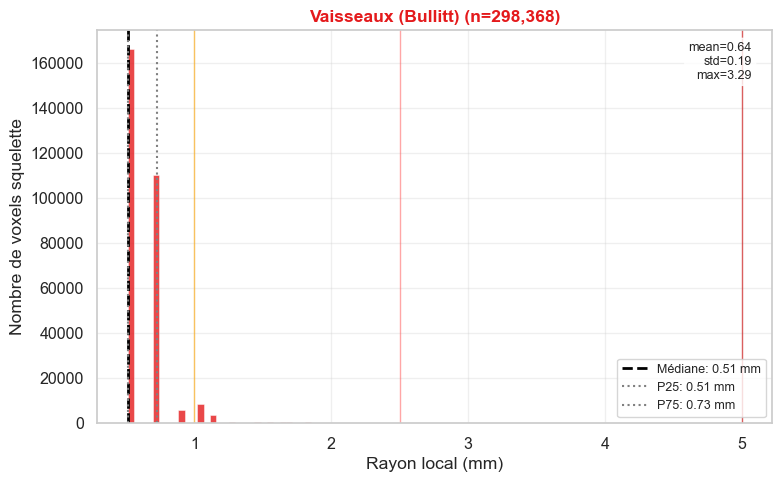

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
info = VESSEL_LABELS[1]
r = profiles[1]['radii']
r = r[r > 0]

ax.hist(r, bins=60, color=info['color'], alpha=0.8, edgecolor='white', linewidth=0.4)
ax.axvline(np.median(r), color='black', ls='--', lw=2, label=f'Médiane: {np.median(r):.2f} mm')
ax.axvline(np.percentile(r, 25), color='gray', ls=':', lw=1.5, label=f'P25: {np.percentile(r,25):.2f} mm')
ax.axvline(np.percentile(r, 75), color='gray', ls=':', lw=1.5, label=f'P75: {np.percentile(r,75):.2f} mm')

for thresh, col in zip([1.0, 2.5, 5.0], ['#FFA500', '#FF6B6B', '#CC0000']):
    ax.axvline(thresh, color=col, ls='-', lw=1, alpha=0.6)

ax.set_title(f"{info['display']} (n={len(r):,})", fontweight='bold', color=info['color'])
ax.set_xlabel('Rayon local (mm)')
ax.set_ylabel('Nombre de voxels squelette')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

txt = f"mean={r.mean():.2f}\nstd={r.std():.2f}\nmax={r.max():.2f}"
ax.text(0.97, 0.97, txt, transform=ax.transAxes, va='top', ha='right',
        fontsize=9, bbox=dict(boxstyle='round', fc='white', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig01_radius_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()


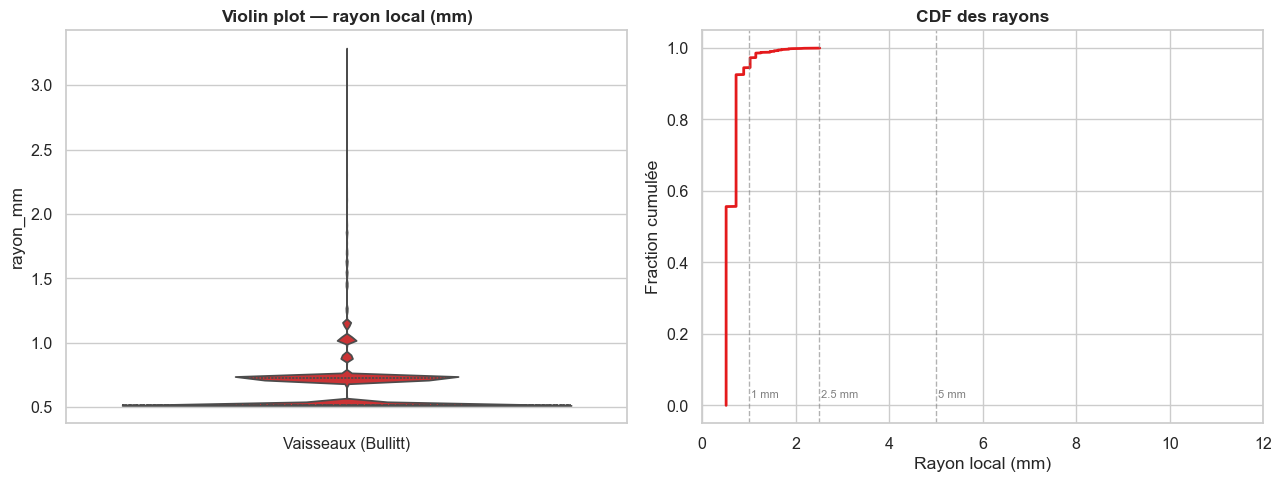

In [33]:
# CDF des rayons + violin plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

violin_df = pd.DataFrame({'rayon_mm': r[r < 20], 'vaisseau': info['display']})
sns.violinplot(data=violin_df, x='vaisseau', y='rayon_mm', color=info['color'],
               inner='quartile', ax=axes[0], cut=0)
axes[0].set_title('Violin plot — rayon local (mm)', fontweight='bold')
axes[0].set_xlabel('')

r_sorted = np.sort(r)
cdf = np.arange(1, len(r_sorted)+1) / len(r_sorted)
step = max(1, len(r_sorted)//2000)
axes[1].plot(r_sorted[::step], cdf[::step], color=info['color'], lw=2)
for thresh, lbl_t in zip([1.0, 2.5, 5.0], ['1 mm', '2.5 mm', '5 mm']):
    axes[1].axvline(thresh, color='gray', ls='--', lw=1, alpha=0.6)
    axes[1].text(thresh+0.05, 0.02, lbl_t, fontsize=8, color='gray')
axes[1].set_title('CDF des rayons', fontweight='bold')
axes[1].set_xlabel('Rayon local (mm)')
axes[1].set_ylabel('Fraction cumulée')
axes[1].set_xlim(0, 12)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig02_radius_violin_cdf.png'), dpi=150, bbox_inches='tight')
plt.show()


## 5. Distribution des Intensités — Vaisseaux vs Parenchyme cérébral

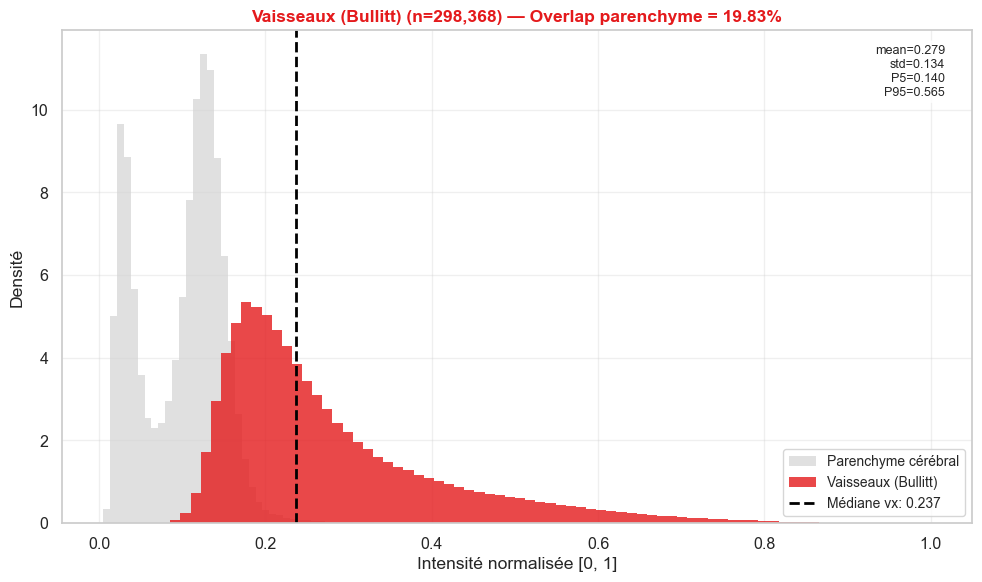

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
ival = profiles[1]['intensity']
ival = ival[(ival >= INTENSITY_RANGE[0]) & (ival <= INTENSITY_RANGE[1])]
parc = parenchyma_intensity[(parenchyma_intensity >= INTENSITY_RANGE[0]) & (parenchyma_intensity <= INTENSITY_RANGE[1])]

ax.hist(parc, bins=80, color='lightgray', alpha=0.7, label='Parenchyme cérébral',
        density=True, edgecolor='none')
ax.hist(ival, bins=80, color=info['color'], alpha=0.8, label=info['display'],
        density=True, edgecolor='none')
ax.axvline(np.median(ival), color='black', ls='--', lw=2, label=f'Médiane vx: {np.median(ival):.3f}')

bins_e = np.linspace(0, 1, 100)
h1, _ = np.histogram(ival, bins=bins_e, density=True)
h2, _ = np.histogram(parc, bins=bins_e, density=True)
overlap = np.trapz(np.minimum(h1, h2), bins_e[:-1])

ax.set_title(f"{info['display']} (n={len(ival):,}) — Overlap parenchyme = {overlap:.2%}",
             fontweight='bold', color=info['color'])
ax.set_xlabel('Intensité normalisée [0, 1]')
ax.set_ylabel('Densité')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

txt = f"mean={ival.mean():.3f}\nstd={ival.std():.3f}\nP5={np.percentile(ival,5):.3f}\nP95={np.percentile(ival,95):.3f}"
ax.text(0.97, 0.97, txt, transform=ax.transAxes, va='top', ha='right',
        fontsize=9, bbox=dict(boxstyle='round', fc='white', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig03_intensity_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()


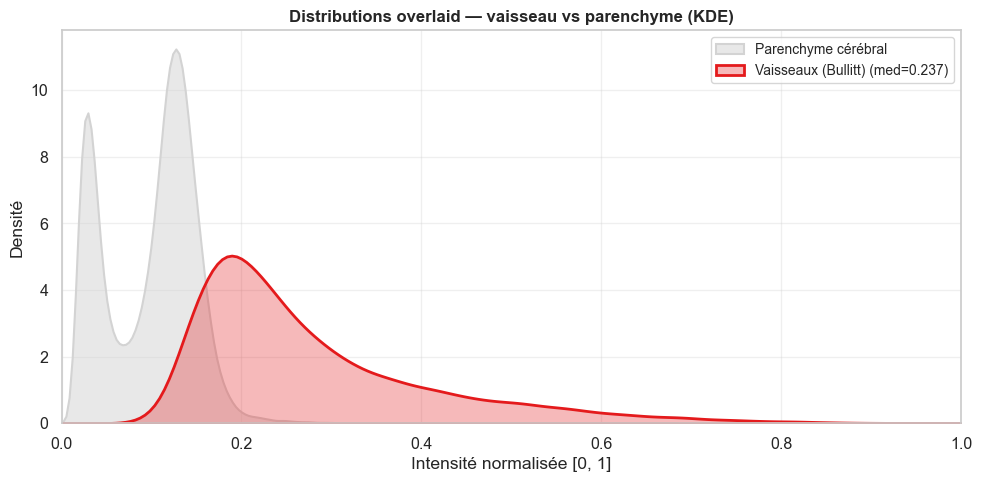

In [35]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('Distributions overlaid — vaisseau vs parenchyme (KDE)', fontsize=12, fontweight='bold')
sns.kdeplot(parc, color='lightgray', fill=True, alpha=0.5, label='Parenchyme cérébral', linewidth=1.5, ax=ax)
ival_sub = ival if len(ival) <= 20000 else np.random.choice(ival, 20000, replace=False)
sns.kdeplot(ival_sub, color=info['color'], fill=True, alpha=0.3,
            label=f"{info['display']} (med={np.median(ival):.3f})", linewidth=2, ax=ax)
ax.set_xlabel('Intensité normalisée [0, 1]')
ax.set_ylabel('Densité')
ax.legend(fontsize=10)
ax.set_xlim(0, 1)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig04_intensity_kde.png'), dpi=150, bbox_inches='tight')
plt.show()


## 6. Carte 2D Rayon × Intensité (Joint Distribution)

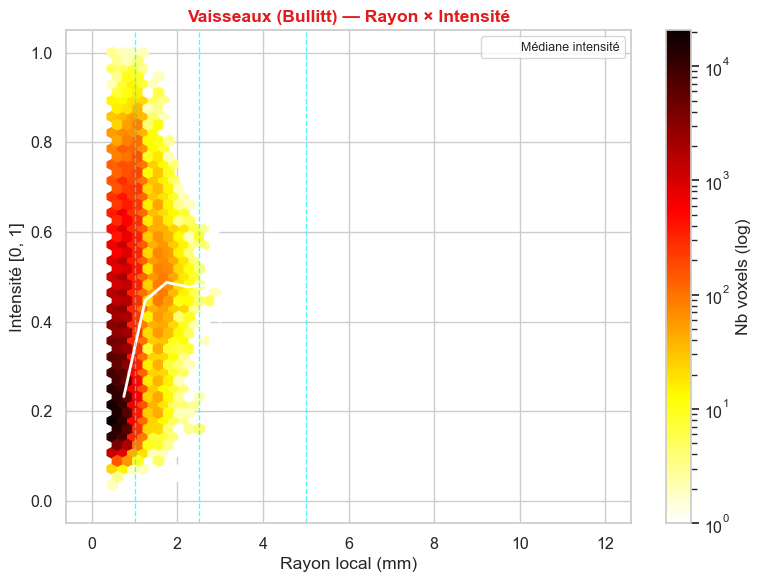

In [50]:
fig, ax = plt.subplots(figsize=(8, 6))
r2  = profiles[1]['radii']
i2  = profiles[1]['intensity']
mask_valid = (r2 > 0) & (r2 < 15) & (i2 >= 0) & (i2 <= 1)
r2, i2 = r2[mask_valid], i2[mask_valid]

hb = ax.hexbin(r2, i2, gridsize=50, mincnt=1, cmap='hot_r', norm=LogNorm(vmin=1),
               extent=[0, 12, 0, 1])
plt.colorbar(hb, ax=ax, label='Nb voxels (log)')

bins = np.arange(0, 12.5, 0.5)
centers, meds = [], []
for b0, b1 in zip(bins[:-1], bins[1:]):
    sel = i2[(r2 >= b0) & (r2 < b1)]
    if len(sel) > 5:
        centers.append((b0+b1)/2)
        meds.append(np.median(sel))
if centers:
    ax.plot(centers, meds, 'w-', lw=2, label='Médiane intensité')

ax.set_title(f"{info['display']} — Rayon × Intensité", fontweight='bold', color=info['color'])
ax.set_xlabel('Rayon local (mm)')
ax.set_ylabel('Intensité [0, 1]')
ax.legend(fontsize=9)
for thresh in [1.0, 2.5, 5.0]:
    ax.axvline(thresh, color='cyan', ls='--', lw=1, alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig05_radius_intensity_2d_density.png'), dpi=150, bbox_inches='tight')
plt.show()


## 7. Analyse par Tranches de Calibre

In [ ]:
# Tableau de statistiques par calibre et par type de vaisseau
records = []
for lbl, info in VESSEL_LABELS.items():
    r  = profiles[lbl]['radii']
    intensite = profiles[lbl]['intensity']
    mask_valid = (r > 0) & (intensite >= 0) & (intensite <= 1)
    r, intensite = r[mask_valid], intensite[mask_valid]

    for i, (r_min, r_max) in enumerate(zip(RADIUS_BINS[:-1], RADIUS_BINS[1:])):
        sel_r  = r[(r >= r_min) & (r < r_max)]
        sel_i  = intensite[(r >= r_min) & (r < r_max)]
        if len(sel_r) == 0:
            continue
        records.append({
            'Vaisseau':           info['display'],
            'Calibre':            RADIUS_LABELS[i],
            'N voxels skel.':     len(sel_r),
            'Rayon moyen (mm)':   f"{sel_r.mean():.2f} ± {sel_r.std():.2f}",
            'Rayon médian':       f"{np.median(sel_r):.2f}",
            'Intensité moyenne':  f"{sel_i.mean():.3f} ± {sel_i.std():.3f}",
            'Intensité médiane':  f"{np.median(sel_i):.3f}",
            'Intensité P5–P95':   f"[{np.percentile(sel_i,5):.3f} ; {np.percentile(sel_i,95):.3f}]",
            '% du vaisseau':      f"{100*len(sel_r)/len(r):.1f}%",
        })

df_calibres = pd.DataFrame(records)

# Affichage
pd.set_option('display.max_colwidth', 30)
print('\n STATISTIQUES PAR CALIBRE ET TYPE DE VAISSEAU')
print('=' * 90)
print(df_calibres.to_string(index=False))
df_calibres.to_csv(os.path.join(OUTPUT_DIR, 'stats_calibre_par_vaisseau.csv'), index=False)
print(f'\n Sauvegardé → stats_calibre_par_vaisseau.csv')



📊 STATISTIQUES PAR CALIBRE ET TYPE DE VAISSEAU
           Vaisseau  Calibre  N voxels skel. Rayon moyen (mm) Rayon médian Intensité moyenne Intensité médiane Intensité P5–P95 % du vaisseau
Vaisseaux (Bullitt) 0.5–1 mm          281968      0.60 ± 0.11         0.51     0.269 ± 0.123             0.233  [0.140 ; 0.527]         94.5%
Vaisseaux (Bullitt) 1–2.5 mm           16325      1.20 ± 0.28         1.03     0.454 ± 0.191             0.460  [0.174 ; 0.771]          5.5%
Vaisseaux (Bullitt) 2.5–5 mm              75      2.67 ± 0.19         2.57     0.449 ± 0.146             0.465  [0.158 ; 0.608]          0.0%

✅ Sauvegardé → stats_calibre_par_vaisseau.csv


In [38]:
print("="*70)
print("  POURCENTAGES EXACTS PAR CALIBRE (sphère inscrite maximale)")
print("="*70)
r4 = profiles[1]['radii']
r4 = r4[r4 > 0]
total = len(r4)
print(f"\n{info['display']:25s} (n = {total:,})")
print("-" * 50)
for i, (r_min, r_max) in enumerate(zip(RADIUS_BINS[:-1], RADIUS_BINS[1:])):
    count = ((r4 >= r_min) & (r4 < r_max)).sum()
    pct = 100 * count / total
    bar = '█' * int(pct / 2) + '░' * (50 - int(pct / 2))
    print(f"  {RADIUS_LABELS[i]:12s} : {bar}  {pct:5.1f}%  ({count:>7,} points)")


  POURCENTAGES EXACTS PAR CALIBRE (sphère inscrite maximale)

Vaisseaux (Bullitt)       (n = 298,368)
--------------------------------------------------
  < 0.5 mm     : ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░    0.0%  (      0 points)
  0.5–1 mm     : ███████████████████████████████████████████████░░░   94.5%  (281,968 points)
  1–2.5 mm     : ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░    5.5%  ( 16,325 points)
  2.5–5 mm     : ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░    0.0%  (     75 points)
  > 5 mm       : ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░    0.0%  (      0 points)


## 8. Séparabilité Vaisseau vs Parenchyme

In [39]:
# Fisher discriminant ratio entre vaisseau et parenchyme (au lieu d'inter-classes,
# puisqu'il n'y a qu'1 seule classe de vaisseau dans Bullitt)

def fisher_score(a: np.ndarray, b: np.ndarray) -> float:
    if len(a) == 0 or len(b) == 0:
        return np.nan
    return (a.mean() - b.mean())**2 / (a.std()**2 + b.std()**2 + 1e-9)

fs_radius_na = np.nan   # pas de comparaison de rayon possible (parenchyme n'a pas de "rayon vasculaire")
fs_intensity = fisher_score(ival, parc)

print('=' * 60)
print('  SÉPARABILITÉ VAISSEAU vs PARENCHYME (Fisher discriminant ratio)')
print('=' * 60)
print(f'  Intensité : {fs_intensity:.3f}  (valeur haute = mieux séparable)')
print(f'  Médiane vaisseau   : {np.median(ival):.3f}')
print(f'  Médiane parenchyme : {np.median(parc):.3f}')


  SÉPARABILITÉ VAISSEAU vs PARENCHYME (Fisher discriminant ratio)
  Intensité : 1.576  (valeur haute = mieux séparable)
  Médiane vaisseau   : 0.237
  Médiane parenchyme : 0.113


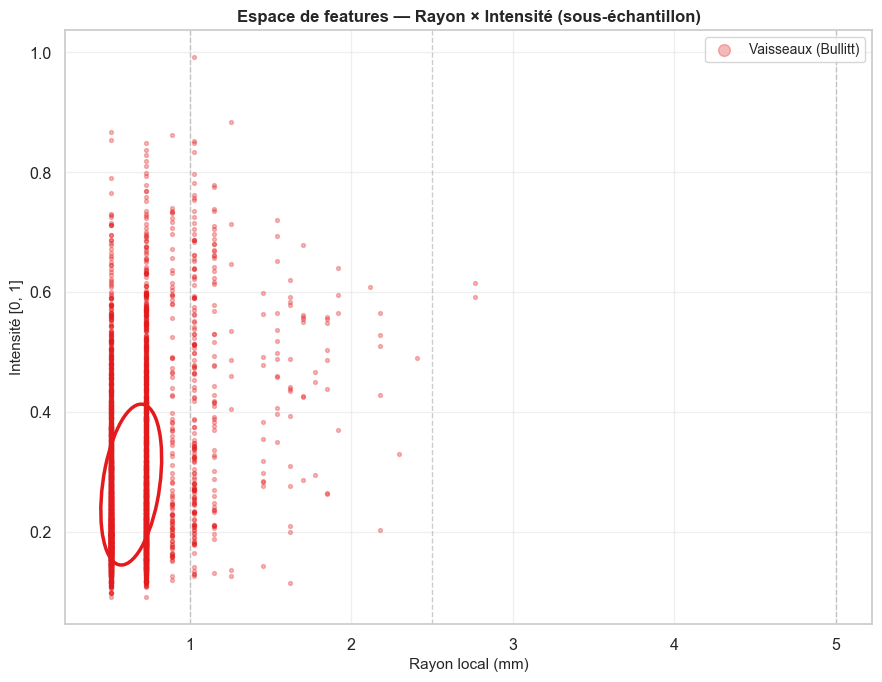

In [40]:
# Scatter rayon × intensité, sous-échantillonné
fig, ax = plt.subplots(figsize=(9, 7))
ax.set_title('Espace de features — Rayon × Intensité (sous-échantillon)', fontsize=12, fontweight='bold')

r5, i5 = profiles[1]['radii'], profiles[1]['intensity']
mask_valid = (r5 > 0) & (r5 < 15) & (i5 >= 0) & (i5 <= 1)
r5, i5 = r5[mask_valid], i5[mask_valid]
n_pts = min(5000, len(r5))
idx = np.random.choice(len(r5), n_pts, replace=False)
ax.scatter(r5[idx], i5[idx], c=info['color'], alpha=0.3, s=8, label=info['display'])

from matplotlib.patches import Ellipse
cov = np.cov(r5, i5)
vals, vecs = np.linalg.eigh(cov)
order = vals.argsort()[::-1]
vals, vecs = vals[order], vecs[:, order]
theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
w, h = 2 * np.sqrt(vals)
ell = Ellipse((r5.mean(), i5.mean()), width=w, height=h, angle=theta,
              edgecolor=info['color'], facecolor='none', lw=2.5, zorder=5)
ax.add_patch(ell)

for thresh in [1.0, 2.5, 5.0]:
    ax.axvline(thresh, color='gray', ls='--', lw=1, alpha=0.4)

ax.set_xlabel('Rayon local (mm)', fontsize=11)
ax.set_ylabel('Intensité [0, 1]', fontsize=11)
ax.legend(fontsize=10, markerscale=3)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig10_feature_space.png'), dpi=150, bbox_inches='tight')
plt.show()


## 9. Seuils Optimaux pour la Segmentation

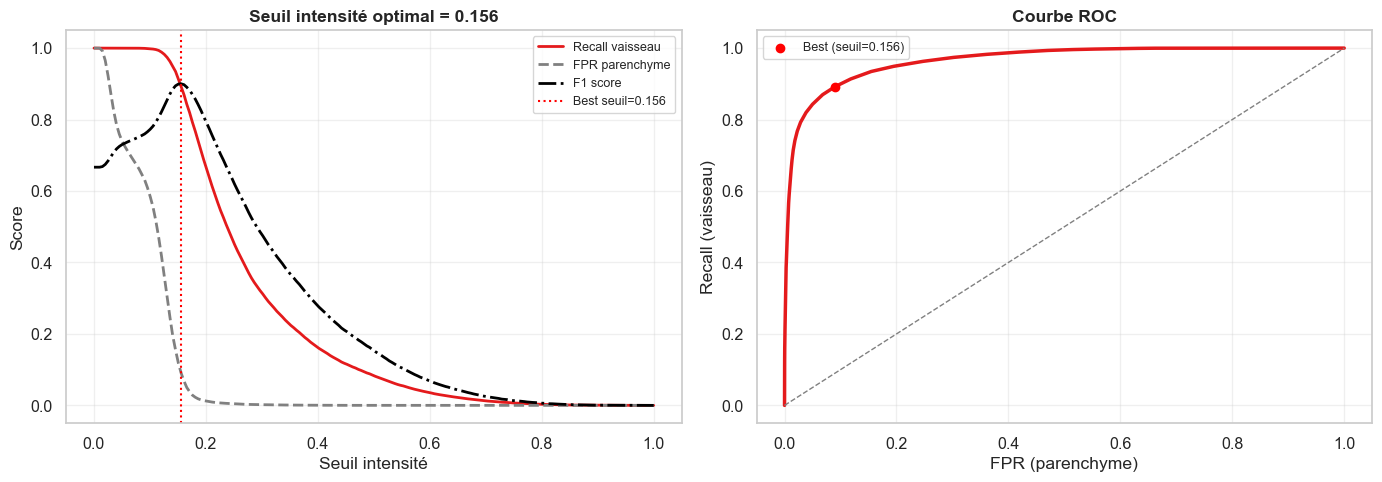

✅ Meilleur seuil d'intensité (F1 max) = 0.156


In [ ]:
# Seuil d'intensité optimal vaisseau vs parenchyme (Recall / FPR / F1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

parc_sample = parc if len(parc) <= 20000 else np.random.choice(parc, 20000, replace=False)
ival_sample = ival if len(ival) <= 20000 else np.random.choice(ival, 20000, replace=False)

thresholds = np.linspace(0, 1, 200)
recall    = np.array([(ival_sample >= t).mean() for t in thresholds])
fpr       = np.array([(parc_sample >= t).mean() for t in thresholds])
precision = recall / (recall + fpr + 1e-9)
f1        = 2 * precision * recall / (precision + recall + 1e-9)

best_t_idx = np.argmax(f1)
best_t = thresholds[best_t_idx]

ax = axes[0]
ax.plot(thresholds, recall, color=info['color'], lw=2, label='Recall vaisseau')
ax.plot(thresholds, fpr, color='gray', lw=2, ls='--', label='FPR parenchyme')
ax.plot(thresholds, f1, color='black', lw=2, ls='-.', label='F1 score')
ax.axvline(best_t, color='red', lw=1.5, ls=':', label=f'Best seuil={best_t:.3f}')
ax.set_title(f'Seuil intensité optimal = {best_t:.3f}', fontweight='bold')
ax.set_xlabel('Seuil intensité')
ax.set_ylabel('Score')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(fpr, recall, color=info['color'], lw=2.5)
ax.plot([0,1],[0,1], color='gray', ls='--', lw=1)
ax.scatter([fpr[best_t_idx]], [recall[best_t_idx]], color='red', zorder=5, label=f'Best (seuil={best_t:.3f})')
ax.set_title('Courbe ROC', fontweight='bold')
ax.set_xlabel('FPR (parenchyme)')
ax.set_ylabel('Recall (vaisseau)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig11_intensity_threshold.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f' Meilleur seuil d\'intensité (F1 max) = {best_t:.3f}')


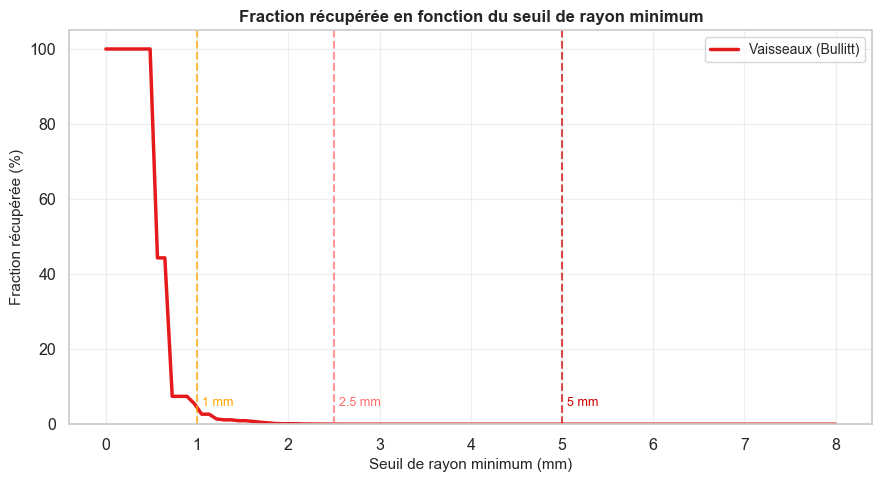

In [42]:
# Fraction récupérée en fonction du seuil de rayon minimum
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title('Fraction récupérée en fonction du seuil de rayon minimum', fontsize=12, fontweight='bold')

r_thresholds = np.linspace(0, 8, 100)
r6 = profiles[1]['radii']
r6 = r6[r6 > 0]
frac = np.array([(r6 >= t).mean() for t in r_thresholds])
ax.plot(r_thresholds, frac * 100, color=info['color'], lw=2.5, label=info['display'])

for thresh, col_t, lbl_t in zip([1.0, 2.5, 5.0], ['#FFA500','#FF6B6B','#CC0000'], ['1 mm', '2.5 mm', '5 mm']):
    ax.axvline(thresh, color=col_t, ls='--', lw=1.5, alpha=0.7)
    ax.text(thresh+0.05, 5, lbl_t, color=col_t, fontsize=9)

ax.set_xlabel('Seuil de rayon minimum (mm)', fontsize=11)
ax.set_ylabel('Fraction récupérée (%)', fontsize=11)
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig12_radius_threshold_recovery.png'), dpi=150, bbox_inches='tight')
plt.show()


## 10. Visualisation Multi-Coupes avec Overlay

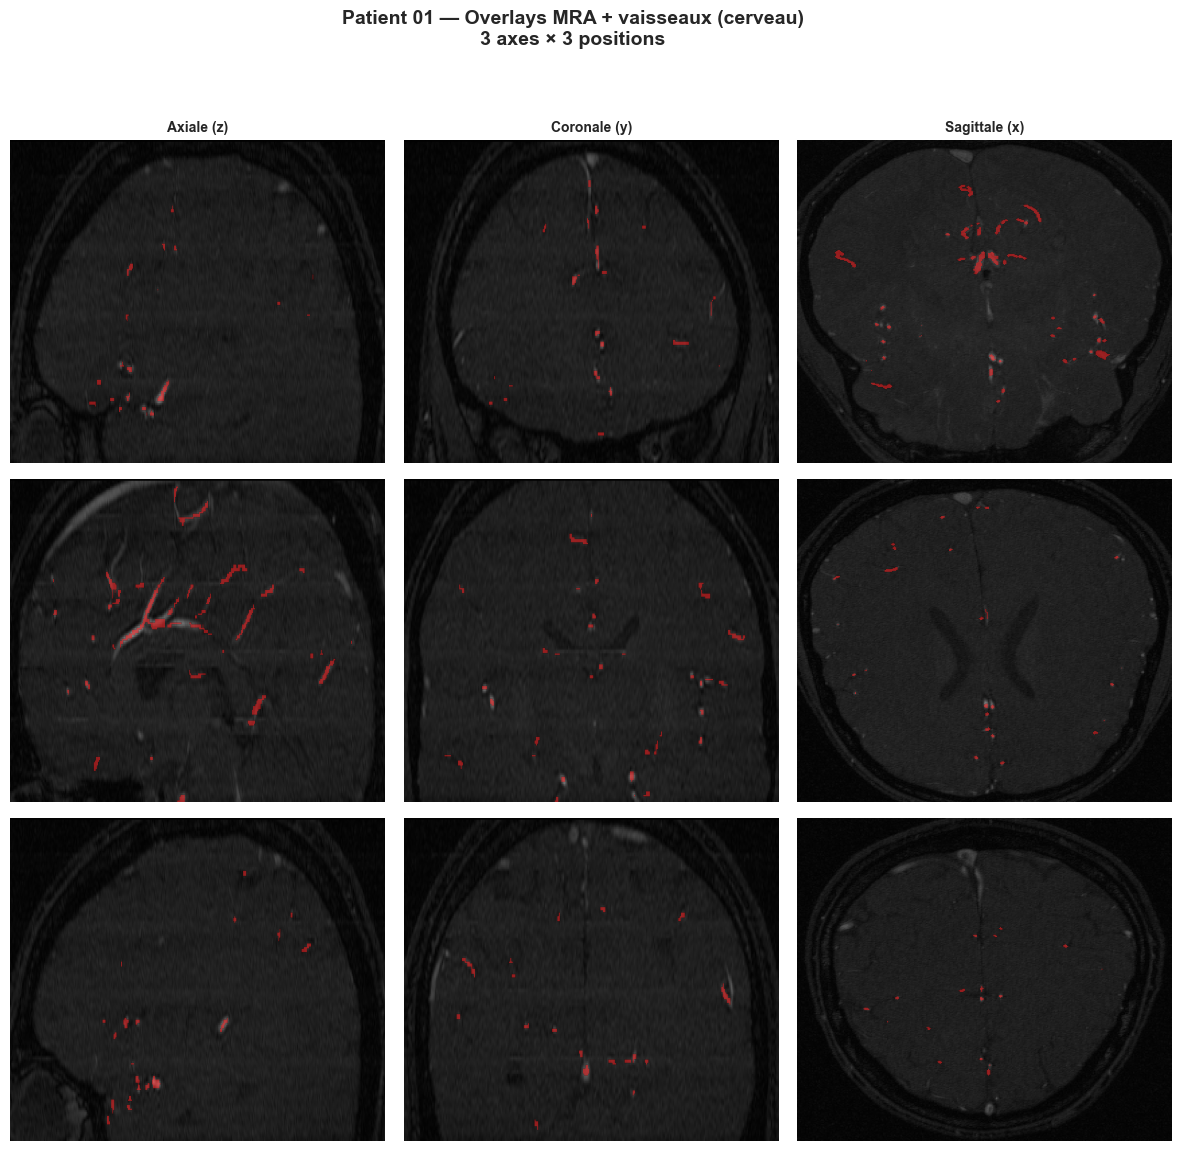

In [43]:
def plot_patient_overlay_full(pid: str, save_dir: str):
    """Affiche 9 coupes (3 axes × 3 positions) avec overlay du masque vaisseau."""
    f = get_files(pid)
    mra, zooms = load_nifti(f['mra'])
    brain, _   = load_nifti(f['brain'])
    vessel, _  = load_nifti(f['vessel'])
    if mra is None:
        return

    vessel_mask = (vessel > 0).astype(np.uint8) if vessel is not None else None
    brain_mask  = (brain > 0) if brain is not None else None

    if brain_mask is not None:
        coords = np.where(brain_mask)
        bounds = [(coords[i].min(), coords[i].max()) for i in range(3)]
    else:
        bounds = [(0, mra.shape[i]-1) for i in range(3)]

    axes_labels = ['Axiale (z)', 'Coronale (y)', 'Sagittale (x)']
    positions   = [0.25, 0.50, 0.75]

    fig = plt.figure(figsize=(15, 13))
    gs  = gridspec.GridSpec(3, 3, hspace=0.05, wspace=0.05)
    fig.suptitle(f'Patient {pid} — Overlays MRA + vaisseaux (cerveau)\n3 axes × 3 positions',
                 fontsize=14, fontweight='bold')

    for row, pos in enumerate(positions):
        for col, axis in enumerate(range(3)):
            ax = fig.add_subplot(gs[row, col])
            lo, hi = bounds[axis]
            idx = int(lo + pos * (hi - lo))
            if axis == 0:
                sl_img = mra[idx, :, :]
                sl_msk = vessel_mask[idx, :, :] if vessel_mask is not None else None
            elif axis == 1:
                sl_img = mra[:, idx, :]
                sl_msk = vessel_mask[:, idx, :] if vessel_mask is not None else None
            else:
                sl_img = mra[:, :, idx]
                sl_msk = vessel_mask[:, :, idx] if vessel_mask is not None else None

            ax.imshow(sl_img.T, cmap='gray', vmin=0, vmax=1, origin='lower', aspect='auto')
            if sl_msk is not None and sl_msk.sum() > 0:
                overlay = np.ma.masked_where(sl_msk == 0, sl_msk)
                ax.imshow(overlay.T, cmap=ListedColormap([VESSEL_LABELS[1]['color']]),
                          alpha=0.6, origin='lower', aspect='auto')
            if row == 0:
                ax.set_title(axes_labels[col], fontsize=10, fontweight='bold')
            ax.axis('off')

    plt.tight_layout()
    out_path = os.path.join(save_dir, f'fig13_overlay_patient_{pid}.png')
    plt.savefig(out_path, dpi=130, bbox_inches='tight')
    plt.show()


if valid_patients:
    plot_patient_overlay_full(valid_patients[0], OUTPUT_DIR)


## 11. Profils d'Intensité sur Lignes de Coupe (Cross-Section)

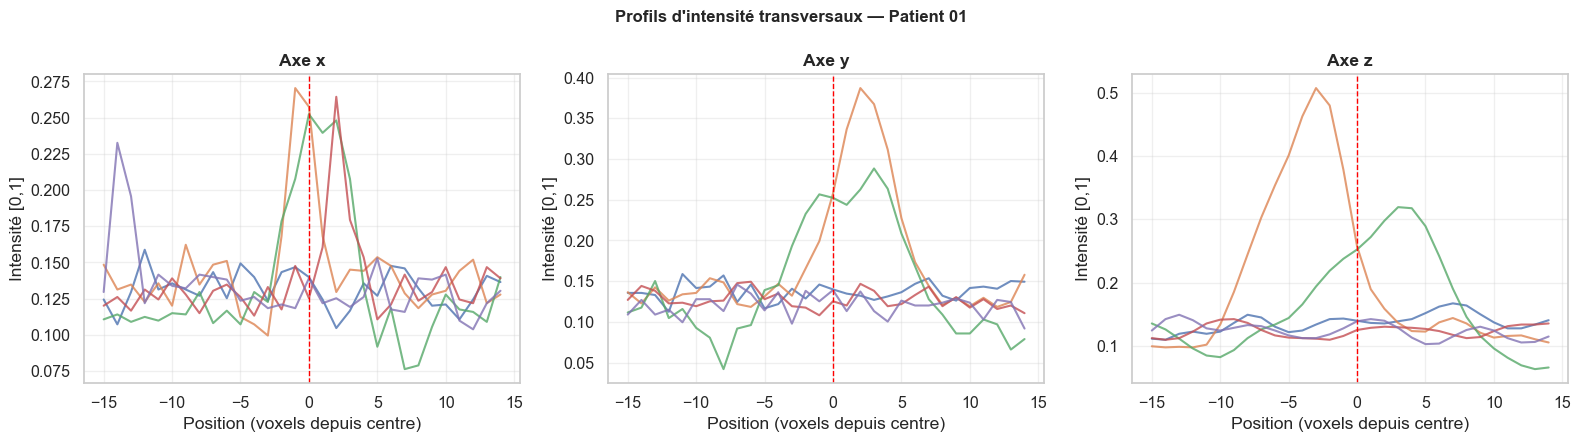

In [44]:
def get_vessel_line_profile(vol, mask, axis=0, n_lines=5, half_width=20):
    """Profils d'intensité transversaux à travers le centre des composantes connexes."""
    profiles_out = []
    labeled, n = ndimage.label(mask)
    if n == 0:
        return profiles_out
    sizes = ndimage.sum(mask, labeled, range(1, n+1))
    order = np.argsort(sizes)[::-1][:n_lines]

    for comp_idx in order:
        comp_mask = (labeled == comp_idx + 1)
        cx, cy, cz = [int(x) for x in ndimage.center_of_mass(comp_mask)]
        if axis == 0:
            lo, hi = max(0, cx-half_width), min(vol.shape[0], cx+half_width)
            profile = vol[lo:hi, cy, cz]
            pos = np.arange(lo, hi) - cx
        elif axis == 1:
            lo, hi = max(0, cy-half_width), min(vol.shape[1], cy+half_width)
            profile = vol[cx, lo:hi, cz]
            pos = np.arange(lo, hi) - cy
        else:
            lo, hi = max(0, cz-half_width), min(vol.shape[2], cz+half_width)
            profile = vol[cx, cy, lo:hi]
            pos = np.arange(lo, hi) - cz
        if len(profile) >= 5:
            profiles_out.append((pos, profile, (cx, cy, cz)))
    return profiles_out


pid_demo = valid_patients[0] if valid_patients else None
if pid_demo:
    f = get_files(pid_demo)
    mra, zooms = load_nifti(f['mra'])
    vessel, _  = load_nifti(f['vessel'])
    vessel_mask = (vessel > 0).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fig.suptitle(f"Profils d'intensité transversaux — Patient {pid_demo}", fontsize=12, fontweight='bold')
    axis_names = ['x', 'y', 'z']
    for ax, axis in zip(axes, range(3)):
        profs = get_vessel_line_profile(mra, vessel_mask, axis=axis, n_lines=5, half_width=15)
        for pos, profile, center in profs:
            ax.plot(pos, profile, alpha=0.8, lw=1.5)
        ax.axvline(0, color='red', ls='--', lw=1)
        ax.set_title(f'Axe {axis_names[axis]}', fontweight='bold')
        ax.set_xlabel('Position (voxels depuis centre)')
        ax.set_ylabel('Intensité [0,1]')
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig14_line_profiles.png'), dpi=150, bbox_inches='tight')
    plt.show()


## 12. Distance Transform : Carte des Rayons en 2D

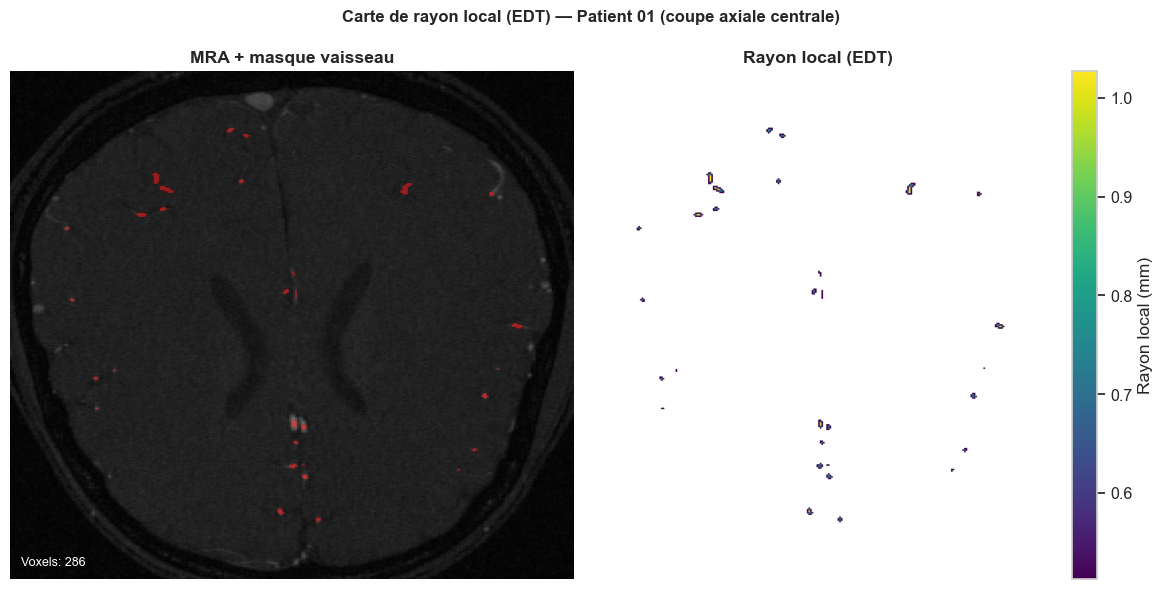

In [45]:
if pid_demo:
    f = get_files(pid_demo)
    mra, zooms = load_nifti(f['mra'])
    brain, _   = load_nifti(f['brain'])
    vessel, _  = load_nifti(f['vessel'])
    vessel_mask = (vessel > 0).astype(np.uint8)

    if brain is not None:
        brain_z = np.where(brain > 0)[2]
        best_z = int(np.median(brain_z))
    else:
        best_z = mra.shape[2] // 2

    sl_mra = mra[:, :, best_z]
    sl_msk = vessel_mask[:, :, best_z]

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(f'Carte de rayon local (EDT) — Patient {pid_demo} (coupe axiale centrale)',
                 fontsize=12, fontweight='bold')

    axes[0].imshow(sl_mra.T, cmap='gray', vmin=0, vmax=1, origin='lower', aspect='auto')
    overlay = np.ma.masked_where(sl_msk == 0, sl_msk)
    axes[0].imshow(overlay.T, cmap=ListedColormap([VESSEL_LABELS[1]['color']]),
                   alpha=0.6, origin='lower', aspect='auto')
    axes[0].set_title('MRA + masque vaisseau', fontweight='bold')
    axes[0].text(0.02, 0.02, f'Voxels: {sl_msk.sum()}', transform=axes[0].transAxes,
                 color='white', fontsize=9, va='bottom')
    axes[0].axis('off')

    if sl_msk.sum() > 0:
        edt_2d = distance_transform_edt(sl_msk, sampling=zooms[:2].tolist())
        edt_display = np.ma.masked_where(sl_msk == 0, edt_2d)
        im = axes[1].imshow(edt_display.T, cmap='viridis', origin='lower', aspect='auto')
        plt.colorbar(im, ax=axes[1], label='Rayon local (mm)')
    axes[1].set_title('Rayon local (EDT)', fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig15_edt_map.png'), dpi=150, bbox_inches='tight')
    plt.show()


## 13. Dashboard Interactif Plotly

In [ ]:
scatter_records = []
r7, i7, pid_arr = profiles[1]['radii'], profiles[1]['intensity'], np.array(profiles[1]['patient'])
mask_v = (r7 > 0) & (r7 < 15) & (i7 >= 0) & (i7 <= 1)
r7, i7, pids = r7[mask_v], i7[mask_v], pid_arr[mask_v]

if len(r7) > 6000:
    idx = np.random.choice(len(r7), 6000, replace=False)
    r7, i7, pids = r7[idx], i7[idx], pids[idx]

for r_val, i_val, p in zip(r7, i7, pids):
    cal = RADIUS_LABELS[0]
    for i, (rmin, rmax) in enumerate(zip(RADIUS_BINS[:-1], RADIUS_BINS[1:])):
        if rmin <= r_val < rmax:
            cal = RADIUS_LABELS[i]
            break
    scatter_records.append({
        'rayon_mm': round(float(r_val), 2),
        'intensite': round(float(i_val), 3),
        'patient': p,
        'calibre': cal,
    })

scatter_df = pd.DataFrame(scatter_records)

fig_dash = px.scatter(
    scatter_df, x='rayon_mm', y='intensite', symbol='calibre',
    hover_data=['patient', 'calibre'],
    opacity=0.5,
    title=' Espace de features vasculaires Bullitt — Rayon × Intensité (interactif)',
    labels={'rayon_mm': 'Rayon local (mm)', 'intensite': 'Intensité [0,1]'},
    height=550,
)
for thresh in [1.0, 2.5, 5.0]:
    fig_dash.add_vline(x=thresh, line_dash='dash', line_color='gray', opacity=0.5,
                       annotation_text=f'{thresh} mm', annotation_position='top')
fig_dash.update_layout(font=dict(family='Arial', size=11))
fig_dash.show()


In [47]:
fig_box = px.box(
    scatter_df, x='calibre', y='intensite',
    title='Distribution intensité par calibre',
    labels={'intensite': 'Intensité [0,1]', 'calibre': 'Calibre'},
    category_orders={'calibre': RADIUS_LABELS},
    height=450, points=False,
)
fig_box.show()


## 14. Tableau de Synthèse pour la Segmentation

In [48]:
print('=' * 80)
print('  SYNTHÈSE DES FEATURES — GUIDE POUR LA SEGMENTATION VASCULAIRE CÉRÉBRALE (BULLITT)')
print('=' * 80)

r8, i8 = profiles[1]['radii'], profiles[1]['intensity']
r8 = r8[r8 > 0]
i8 = i8[(i8 >= 0) & (i8 <= 1)]

print(f"\n  {'─'*70}")
print(f"  {info['display'].upper()}")
print(f"  {'─'*70}")
print(f"  Rayon local (squelette) :")
print(f"    Médiane : {np.median(r8):.2f} mm   |  Moyenne : {r8.mean():.2f} ± {r8.std():.2f} mm")
print(f"    P5–P95  : [{np.percentile(r8,5):.2f} ; {np.percentile(r8,95):.2f}] mm   |  Max : {r8.max():.2f} mm")
print(f"  Intensité (squelette, normalisée [0,1]) :")
print(f"    Médiane : {np.median(i8):.3f}   |  Moyenne : {i8.mean():.3f} ± {i8.std():.3f}")
print(f"    P5–P95  : [{np.percentile(i8,5):.3f} ; {np.percentile(i8,95):.3f}]")
print(f"  Seuil d'intensité optimal (F1) : {best_t:.3f}")
print(f"  Répartition par calibre :")
for i, (r_min, r_max) in enumerate(zip(RADIUS_BINS[:-1], RADIUS_BINS[1:])):
    pct = 100 * ((r8 >= r_min) & (r8 < r_max)).sum() / len(r8)
    bar = '█' * int(pct / 5) + '░' * (20 - int(pct / 5))
    print(f"    {RADIUS_LABELS[i]:12s} : {bar}  {pct:5.1f}%")

print(f"\n{'=' * 80}")
print('  Fichiers générés dans :', OUTPUT_DIR)
for fn in sorted(os.listdir(OUTPUT_DIR)):
    if fn.endswith(('.png', '.csv')):
        sz = os.path.getsize(os.path.join(OUTPUT_DIR, fn)) / 1024
        print(f"    {fn:55s}  {sz:>8.1f} KB")
print(f"{'=' * 80}")


  SYNTHÈSE DES FEATURES — GUIDE POUR LA SEGMENTATION VASCULAIRE CÉRÉBRALE (BULLITT)

  ──────────────────────────────────────────────────────────────────────
  VAISSEAUX (BULLITT)
  ──────────────────────────────────────────────────────────────────────
  Rayon local (squelette) :
    Médiane : 0.51 mm   |  Moyenne : 0.64 ± 0.19 mm
    P5–P95  : [0.51 ; 1.03] mm   |  Max : 3.29 mm
  Intensité (squelette, normalisée [0,1]) :
    Médiane : 0.237   |  Moyenne : 0.279 ± 0.134
    P5–P95  : [0.140 ; 0.565]
  Seuil d'intensité optimal (F1) : 0.156
  Répartition par calibre :
    < 0.5 mm     : ░░░░░░░░░░░░░░░░░░░░    0.0%
    0.5–1 mm     : ██████████████████░░   94.5%
    1–2.5 mm     : █░░░░░░░░░░░░░░░░░░░    5.5%
    2.5–5 mm     : ░░░░░░░░░░░░░░░░░░░░    0.0%
    > 5 mm       : ░░░░░░░░░░░░░░░░░░░░    0.0%

  Fichiers générés dans : /Users/arslenebouhadjera/Stage_Arslène_2026/Documents/StageNoé2025/pipeline-vessel-enhancement-master/resultats_vaisseaux_bullitt
    fig01_radius_distributio